<a href="https://colab.research.google.com/github/brunobobadilla06/Proyecto-Final---Ciencia-de-Datos-I/blob/main/Proyecto_Final_Bobadilla_Ciencia_de_datos_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Ciencia de Datos

## Predicción del abandono del tratamiento en una plataforma digital de terapia


In [1]:
# Librerías principales para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de scikit-learn para modelado
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Selección de variables
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Modelo de clasificación
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Configuración visual
sns.set(style="whitegrid")
np.random.seed(42)

Creacion de dataset

In [2]:
# Tamaño del dataset
n = 1000

# Variables base
edad_paciente = np.random.randint(18, 65, n)

genero = np.random.choice(
    ["Masculino", "Femenino", "No binario"],
    size=n,
    p=[0.45, 0.45, 0.10]
)

ciudad = np.random.choice(
    ["Buenos Aires", "Córdoba", "Rosario", "Mendoza", "La Plata"],
    size=n
)

tipo_terapia = np.random.choice(
    ["Ansiedad", "Depresión", "Estrés", "Terapia de pareja", "Autoestima"],
    size=n,
    p=[0.28, 0.22, 0.25, 0.12, 0.13]
)

modalidad = np.random.choice(
    ["Online", "Presencial"],
    size=n,
    p=[0.65, 0.35]
)

sesiones_mes = np.random.randint(1, 8, n)
costo_sesion = np.random.randint(8000, 20000, n)
tiempo_espera_dias = np.random.randint(1, 20, n)

# Efectos para hacer la satisfacción más realista
efecto_modalidad = np.where(modalidad == "Online", 0.3, 0)

efecto_terapia = np.select(
    [
        tipo_terapia == "Ansiedad",
        tipo_terapia == "Depresión",
        tipo_terapia == "Estrés",
        tipo_terapia == "Terapia de pareja",
        tipo_terapia == "Autoestima"
    ],
    [0.4, -0.2, 0.2, 0.1, 0.5],
    default=0
)

# Variable satisfacción con relaciones simuladas
satisfaccion = (
    4
    + sesiones_mes * 0.5
    - tiempo_espera_dias * 0.08
    + efecto_modalidad
    + efecto_terapia
    + np.random.normal(0, 1.2, n)
)

# Limitar valores entre 1 y 10
satisfaccion = np.clip(np.round(satisfaccion), 1, 10)

# Probabilidad de abandono
prob_abandono = 0.15 + (tiempo_espera_dias / 25) - (satisfaccion / 20)
prob_abandono = np.clip(prob_abandono, 0.05, 0.90)

# Variable objetivo binaria
abandono = np.where(np.random.rand(n) < prob_abandono, 1, 0)

# Crear DataFrame
datos = pd.DataFrame({
    "edad_paciente": edad_paciente,
    "genero": genero,
    "ciudad": ciudad,
    "tipo_terapia": tipo_terapia,
    "modalidad": modalidad,
    "sesiones_mes": sesiones_mes,
    "costo_sesion": costo_sesion,
    "satisfaccion": satisfaccion,
    "tiempo_espera_dias": tiempo_espera_dias,
    "abandono": abandono
})

# Mostrar primeras filas
datos.head()

,edad_paciente,genero,ciudad,tipo_terapia,modalidad,sesiones_mes,costo_sesion,satisfaccion,tiempo_espera_dias,abandono
0,56,Masculino,La Plata,Estrés,Online,5,13413,6.0,16,1
1,46,Femenino,Rosario,Depresión,Online,5,9269,5.0,14,0
2,32,Masculino,Córdoba,Estrés,Presencial,1,15868,3.0,14,0
3,60,Femenino,Mendoza,Autoestima,Online,7,10603,9.0,1,0
4,25,Femenino,Rosario,Depresión,Online,5,13961,8.0,3,0


Introduccion de valores faltantes

In [3]:
# Introducir aproximadamente 3% de valores faltantes en todo el dataset
mask = np.random.rand(*datos.shape) < 0.03
datos = datos.mask(mask)

# Ver primeras filas
datos.head()

,edad_paciente,genero,ciudad,tipo_terapia,modalidad,sesiones_mes,costo_sesion,satisfaccion,tiempo_espera_dias,abandono
0,56.0,Masculino,La Plata,Estrés,Online,5.0,NaN,6.0,16.0,1.0
1,46.0,Femenino,Rosario,Depresión,NaN,5.0,9269.0,5.0,14.0,0.0
2,32.0,Masculino,Córdoba,Estrés,Presencial,1.0,NaN,3.0,14.0,0.0
3,60.0,Femenino,Mendoza,Autoestima,Online,NaN,10603.0,9.0,1.0,0.0
4,25.0,Femenino,Rosario,Depresión,Online,5.0,13961.0,8.0,3.0,0.0


Revision

In [4]:
# Dimensiones del dataset
datos.shape
# Tipos de datos
datos.info()
# Cantidad de valores faltantes por variable
datos.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edad_paciente       972 non-null    float64
 1   genero              969 non-null    object 
 2   ciudad              969 non-null    object 
 3   tipo_terapia        959 non-null    object 
 4   modalidad           974 non-null    object 
 5   sesiones_mes        977 non-null    float64
 6   costo_sesion        974 non-null    float64
 7   satisfaccion        973 non-null    float64
 8   tiempo_espera_dias  970 non-null    float64
 9   abandono            966 non-null    float64
dtypes: float64(6), object(4)
memory usage: 78.3+ KB


,0
edad_paciente,28
genero,31
ciudad,31
tipo_terapia,41
modalidad,26
sesiones_mes,23
costo_sesion,26
satisfaccion,27
tiempo_espera_dias,30
abandono,34


Dimensiones

In [5]:
# Variables predictoras
X = datos.drop("abandono", axis=1)

# Variable objetivo
y = datos["abandono"]

# Mostrar dimensiones
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1000, 9)
Dimensión de y: (1000,)


Entrenamiento y prueba

In [7]:

# Eliminar filas donde la variable objetivo tenga valores faltantes
datos = datos.dropna(subset=["abandono"]).copy()
# Variables predictoras
X = datos.drop("abandono", axis=1)

# Variable objetivo
y = datos["abandono"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (772, 9)
X_test: (194, 9)
y_train: (772,)
y_test: (194,)


Identificación de variables numéricas y categóricas

In [8]:
# Identificar columnas numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Columnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Columnas numéricas: ['edad_paciente', 'sesiones_mes', 'costo_sesion', 'satisfaccion', 'tiempo_espera_dias']
Columnas categóricas: ['genero', 'ciudad', 'tipo_terapia', 'modalidad']


Preprocesamiento

In [9]:
# Pipeline para variables numéricas
transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="mean")),
    ("escalador", StandardScaler())
])

# Pipeline para variables categóricas
transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesador general
preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, columnas_numericas),
    ("cat", transformador_categorico, columnas_categoricas)
])

Feature Selection

In [10]:
# Método de selección de variables
selector_variables = SelectKBest(score_func=mutual_info_classif, k=8)

In [11]:
# Modelo de clasificación
modelo = LogisticRegression(max_iter=1000, random_state=42)

Pipeline completo

In [12]:
# Crear pipeline completo
pipeline_final = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("seleccion_variables", selector_variables),
    ("modelo", modelo)
])

Entrenamiento del modelo

In [13]:
# Entrenar el pipeline
pipeline_final.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer()),
                                                                  ('escalador',
                                                                   StandardScaler())]),
                                                  ['edad_paciente',
                                                   'sesiones_mes',
                                                   'costo_sesion',
                                                   'satisfaccion',
                                                   'tiempo_espera_dias']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['genero', 'ciudad',
                                                   'tipo_terapia',
                                                   'modalidad'])])),
                ('seleccion_variables',
                 SelectKBest(k=8,
                             score_func=<function mutual_info_classif at 0x7f5e3e5e7420>)),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

Predicciones

In [14]:
# Predicciones de clase
y_pred = pipeline_final.predict(X_test)

# Probabilidades estimadas para la clase 1
y_prob = pipeline_final.predict_proba(X_test)[:, 1]

Métricas básicas

In [15]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Mostrar resultados
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))
print("ROC AUC:", round(roc_auc, 3))

Accuracy: 0.722
Precision: 0.583
Recall: 0.452
F1-score: 0.509
ROC AUC: 0.773


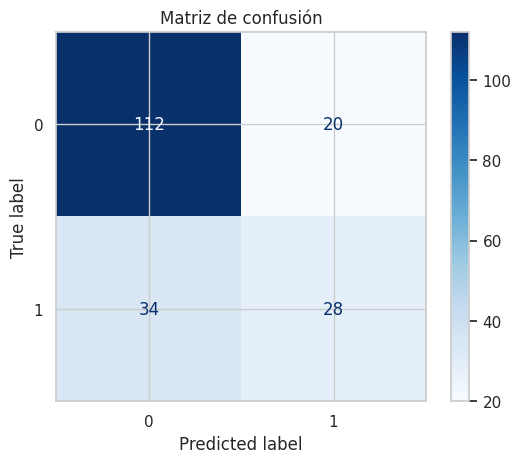

In [16]:
# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

Reporte de clasificación

In [17]:
# Reporte completo
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       132
         1.0       0.58      0.45      0.51        62

    accuracy                           0.72       194
   macro avg       0.68      0.65      0.66       194
weighted avg       0.71      0.72      0.71       194



Curva ROC

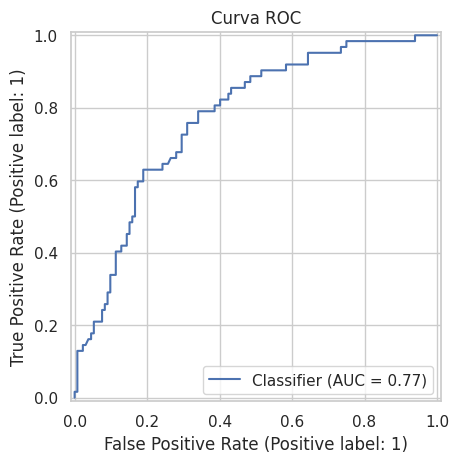

In [18]:
# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Curva ROC")
plt.show()

Variables fueron seleccionadas

In [19]:
# Obtener nombres de columnas luego del preprocesamiento
nombres_columnas = pipeline_final.named_steps["preprocesamiento"].get_feature_names_out()

# Obtener máscara de variables seleccionadas
mascara_seleccionadas = pipeline_final.named_steps["seleccion_variables"].get_support()

# Filtrar variables elegidas
variables_seleccionadas = nombres_columnas[mascara_seleccionadas]

print("Variables seleccionadas por SelectKBest:")
for variable in variables_seleccionadas:
    print(variable)

Variables seleccionadas por SelectKBest:
num__sesiones_mes
num__satisfaccion
num__tiempo_espera_dias
cat__ciudad_Rosario
cat__tipo_terapia_Ansiedad
cat__tipo_terapia_Autoestima
cat__tipo_terapia_Depresión
cat__modalidad_Online


## Interpretación de resultados

Luego de aplicar el preprocesamiento, la selección de variables y entrenar un modelo de regresión logística, se obtuvieron métricas que permiten evaluar el rendimiento del clasificador.

Las métricas calculadas muestran qué tan bien el modelo logra identificar a los pacientes que abandonan el tratamiento y a los que no. En particular:

- un valor alto de **accuracy** indica un buen nivel general de aciertos,
- **precision** y **recall** permiten analizar el comportamiento del modelo sobre la clase abandono,
- el **F1-score** resume el equilibrio entre ambas,
- y el **ROC AUC** permite evaluar la capacidad discriminativa del modelo.

Además, la selección de variables ayuda a identificar cuáles son los atributos más relevantes en la predicción del abandono. En este tipo de problema, es esperable que variables como el tiempo de espera, la satisfacción y la cantidad de sesiones tengan una participación importante.

Conclusiones
## Conclusiones finales

En este proyecto final se desarrolló un modelo de clasificación para predecir el abandono del tratamiento en una plataforma digital de terapia psicológica, utilizando el mismo dataset trabajado previamente en la primera entrega.

En primer lugar, se realizó el preprocesamiento de los datos, contemplando el tratamiento de valores faltantes, la transformación de variables categóricas y el escalado de variables numéricas. Luego, se aplicó un método de selección de variables (**SelectKBest**) con el fin de reducir la dimensionalidad y conservar únicamente las variables más relevantes para el problema.

Posteriormente, se entrenó un modelo de **Regresión Logística**, adecuado para problemas de clasificación binaria. La evaluación mediante métricas básicas como accuracy, precision, recall, F1-score y ROC AUC permitió validar el comportamiento del modelo sobre el conjunto de prueba.

Los resultados obtenidos muestran que es posible predecir el abandono del tratamiento a partir de las variables disponibles en el dataset. Asimismo, el análisis de las variables seleccionadas sugiere que factores como el tiempo de espera, la satisfacción y la frecuencia de sesiones pueden tener un papel importante en la probabilidad de abandono.

Como conclusión general, este trabajo permitió avanzar desde una etapa exploratoria hacia una etapa predictiva, integrando herramientas fundamentales de ciencia de datos como preprocesamiento, feature selection, modelado y evaluación. En futuras mejoras del proyecto podrían probarse otros algoritmos de clasificación, ajustar hiperparámetros o incorporar validación cruzada para optimizar el rendimiento del modelo.

Tabla resumen de métricas

In [20]:
# Tabla resumen de métricas
metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
    "Valor": [accuracy, precision, recall, f1, roc_auc]
})

metricas

,Métrica,Valor
0,Accuracy,0.721649
1,Precision,0.583333
2,Recall,0.451613
3,F1-score,0.509091
4,ROC AUC,0.772972
